# V2 Pipeline - Phase 1: Phân tích Khám phá Dữ liệu (EDA) & Kỹ thuật Đặc trưng (MIMIC)

Thực hiện theo chỉ đạo chuyên môn:
1. **Nạp dữ liệu MIMIC**: `data/features/mimic_train_features_advanced.csv`.
2. **Rà soát thuộc tính phân loại**: One-Hot Encoding cho các biến phân loại (nếu có).
3. **Khảo sát độ biến thiên**: Thống kê độ lệch chuẩn & độ biến thiên của các đặc trưng thô.
4. **Mean Imputation**: Xử lý nhiễu bằng `SimpleImputer(strategy='mean')`.
5. **Tạo 2 tập Scaled V2**: Min-Max Scaling (`v2_mimic_minmax_scaled.csv`) vs Z-Score (`v2_mimic_zscore_scaled.csv`).

In [1]:
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')
print('✅ Nạp thành công thư viện EDA V2 cho MIMIC!')


✅ Nạp thành công thư viện EDA V2 cho MIMIC!


### 1. Nạp Dữ Liệu Thô & Kiểm tra Biến Phân Loại

In [2]:
data_candidates = ['../../../data/features/mimic_train_features_advanced.csv', '../../data/features/mimic_train_features_advanced.csv', 'data/features/mimic_train_features_advanced.csv']
data_path = next((p for p in data_candidates if os.path.exists(p)), None)
df_raw = pd.read_csv(data_path)
print(f'Nạp dữ liệu thành công từ: {data_path}')
print(f'Kích thước dữ liệu thô: {df_raw.shape[0]} mẫu | {df_raw.shape[1]} cột')
cat_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
if cat_cols:
    df_processed = pd.get_dummies(df_raw, columns=cat_cols, drop_first=True)
    print('✅ Đã áp dụng One-Hot Encoding!')
else:
    df_processed = df_raw.copy()
    print('ℹ️ Tất cả đặc trưng đều là dạng số (Numerical).')


Nạp dữ liệu thành công từ: ../../../data/features/mimic_train_features_advanced.csv
Kích thước dữ liệu thô: 1202 mẫu | 17 cột
ℹ️ Tất cả đặc trưng đều là dạng số (Numerical).


### 2. Thống Kê Độ Biến Thiên Dữ Liệu Thô (Variance Analysis)

In [3]:
feature_cols = [c for c in df_processed.columns if c != 'status']
X_raw = df_processed[feature_cols]
y = df_processed['status']
stats_df = pd.DataFrame({
    'Mean': X_raw.mean(),
    'Std_Dev': X_raw.std(),
    'Variance': X_raw.var(),
    'Min': X_raw.min(),
    'Max': X_raw.max(),
    'Range': X_raw.max() - X_raw.min()
}).sort_values(by='Variance', ascending=False)
print('--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ MIMIC ---\n')
print(stats_df.round(4).to_string())


--- BẢNG THỐNG KÊ ĐỘ BIẾN THIÊN CÁC ĐẶC TRƯNG THÔ MIMIC ---

                 Mean   Std_Dev    Variance       Min        Max     Range
Mean_NN      722.5807  167.3750  28014.3870  456.1231  1255.6522  799.5291
RMSSD        151.6692  114.4291  13094.0129    6.2470   691.7986  685.5516
SD2          113.1738   87.3974   7638.3025    3.6730   542.6469  538.9738
SDNN         112.8932   84.4066   7124.4702    4.2922   520.0803  515.7882
SD1          107.1919   80.8791   6541.4333    4.4151   488.4410  484.0259
pNN50         47.9080   33.0965   1095.3802    0.0000   100.0000  100.0000
LF_norm       30.4046   19.1046    364.9842    0.1121    93.7846   93.6725
HF_norm       69.5954   19.1046    364.9842    6.2154    99.8879   93.6725
HR_mean       87.2400   18.8515    355.3774   47.7839   131.5434   83.7595
NN50          19.5624   14.4130    207.7351    0.0000    47.0000   47.0000
CV            16.2910   11.9669    143.2077    0.8004    58.9153   58.1149
LF_HF_Ratio    0.6303    0.9020      0.

### 3. Xử lý Mean Imputation & Xuất Dữ Liệu Scaled (Min-Max vs Z-Score)

In [4]:
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_raw)
X_imputed_df = pd.DataFrame(X_imputed, columns=feature_cols)

minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(minmax_scaler.fit_transform(X_imputed_df), columns=feature_cols)
df_minmax['status'] = y.values

zscore_scaler = StandardScaler()
df_zscore = pd.DataFrame(zscore_scaler.fit_transform(X_imputed_df), columns=feature_cols)
df_zscore['status'] = y.values

save_dir_candidates = ['../../../data/features', '../../data/features', 'data/features']
save_dir = next((d for d in save_dir_candidates if os.path.exists(os.path.dirname(d))), '../../data/features')
os.makedirs(save_dir, exist_ok=True)

path_minmax = os.path.join(save_dir, 'v2_mimic_minmax_scaled.csv')
path_zscore = os.path.join(save_dir, 'v2_mimic_zscore_scaled.csv')
df_minmax.to_csv(path_minmax, index=False)
df_zscore.to_csv(path_zscore, index=False)
print(f'✅ Đã lưu Min-Max Scaled vào: {path_minmax}')
print(f'✅ Đã lưu Z-Score Scaled vào: {path_zscore}')


✅ Đã lưu Min-Max Scaled vào: ../../../data/features\v2_mimic_minmax_scaled.csv
✅ Đã lưu Z-Score Scaled vào: ../../../data/features\v2_mimic_zscore_scaled.csv


### 4. Trực quan hóa So sánh Phân phối Thô vs Min-Max vs Z-Score

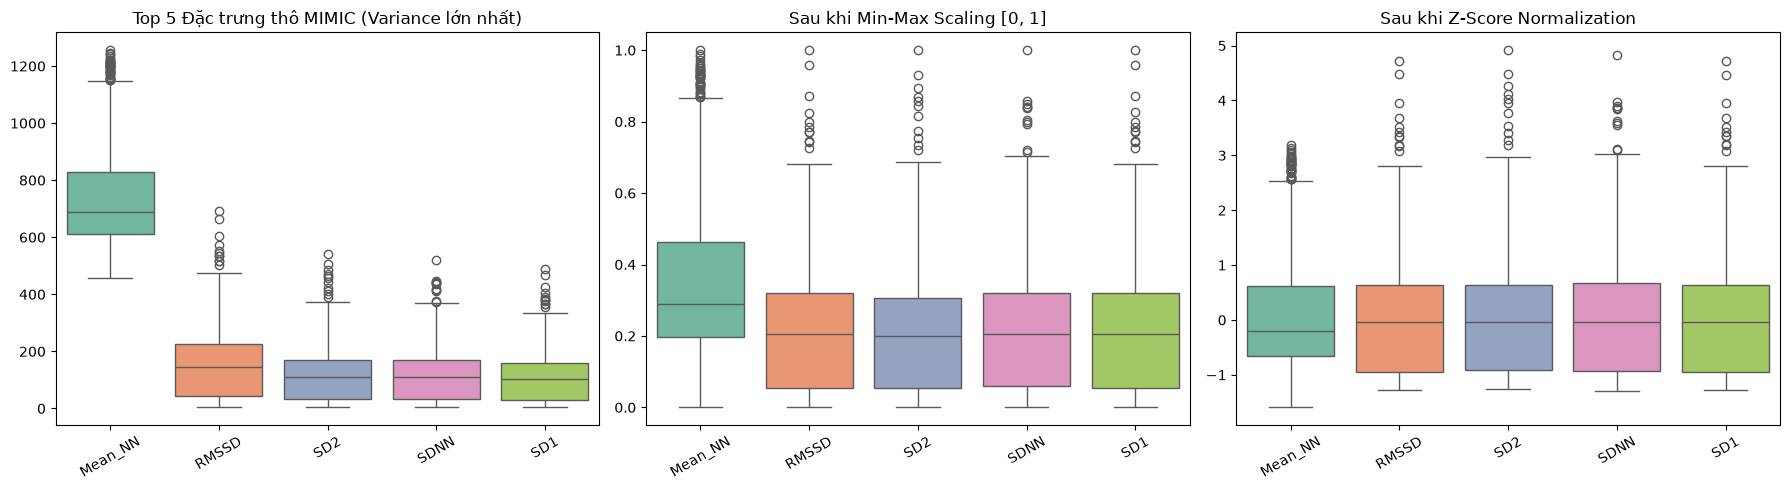

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top_5_var_cols = stats_df.index[:5].tolist()
sns.boxplot(data=X_raw[top_5_var_cols], ax=axes[0], palette='Set2')
axes[0].set_title('Top 5 Đặc trưng thô MIMIC (Variance lớn nhất)')
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_minmax[top_5_var_cols], ax=axes[1], palette='Set2')
axes[1].set_title('Sau khi Min-Max Scaling [0, 1]')
axes[1].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_zscore[top_5_var_cols], ax=axes[2], palette='Set2')
axes[2].set_title('Sau khi Z-Score Normalization')
axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()
